##Customer Churn Risk & AI Retention Advisor

##Import all Libraries

In [71]:
import os
import json
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
#classification algorithm
from sklearn.linear_model import LogisticRegression
#evaluation libraries
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score
# Removed: matplotlib.use('Agg') because it prevents plots from showing inline.
import joblib
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
#KNN
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.gridspec import GridSpec
pd.set_option('display.max_columns', 100)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [2]:
#csv -coma separated values
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [10]:
#copy original data for preprocessing
df=data.copy()

###Part 1: Business Framing & Exploratory Analysis

###Task 1: Explore the Data as a KPI Story

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.shape

(7043, 21)

In [13]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [34]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [14]:
# ---- Task 1: KPI story ----
overall_churn = (df['Churn'] == 'Yes').mean()
print(f"\nOverall churn rate: {overall_churn:.4f} ({overall_churn*100:.2f}%)")


Overall churn rate: 0.2654 (26.54%)


In [15]:
by_contract = df.groupby('Contract')['Churn'].apply(lambda s: (s == 'Yes').mean())
print("\nChurn rate by contract type:")
print(by_contract)


Churn rate by contract type:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


In [16]:
counts_by_contract = df['Contract'].value_counts()
print("\nCustomer counts by contract:")
print(counts_by_contract)


Customer counts by contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [27]:
# Target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [29]:
#correlation between Churn and tenure
correlation = df["tenure"].corr(df["Churn"])
print("Correlation between Tenure and Churn:", correlation)

Correlation between Tenure and Churn: -0.3522286701130772


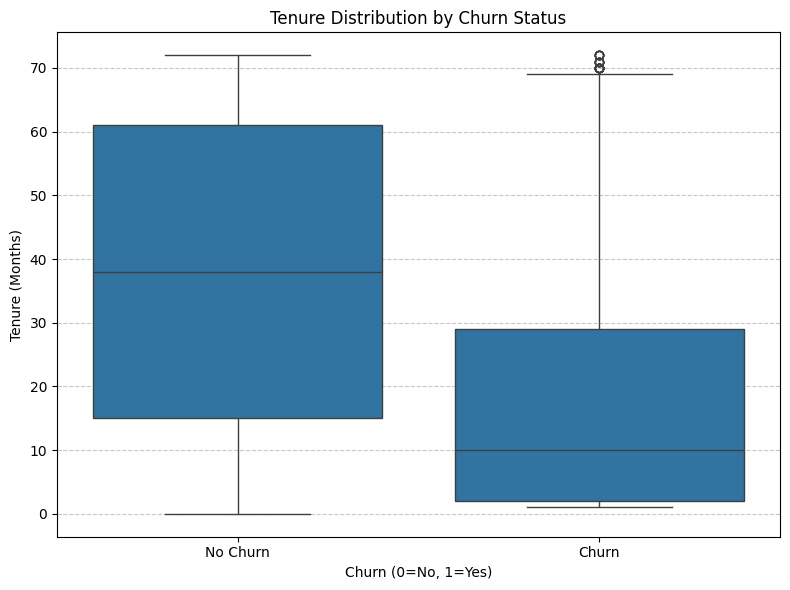

In [30]:
# Visualize the relationship between tenure and Churn
fig = plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure (Months)')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The box plot above illustrates the distribution of  for customers who churned (Churn=1) versus those who did not churn (Churn=0).

**Observations:**
*   **Lower Tenure for Churned Customers**: Customers who churned tend to have significantly lower tenure (fewer months with the service) compared to those who did not churn. The median tenure for churned customers is much lower than for non-churned customers.
*   **Wider Range for Non-Churned Customers**: The distribution of tenure for non-churned customers is much wider, indicating that many long-term customers remain with the service.
*   **Negative Correlation**: The negative correlation coefficient further confirms that as tenure increases, the likelihood of churn decreases.

This suggests that **tenure is a strong indicator of churn**, with newer customers being more prone to churn.

In [17]:
# ---- Task 2: Cleaning ----
print("\n--- TotalCharges inspection ---")
print("dtype before:", df['TotalCharges'].dtype)
# TotalCharges is stored as object due to blank strings for brand-new customers
bad_mask = df['TotalCharges'].str.strip() == ''
print("Rows with blank TotalCharges:", bad_mask.sum())
print(df.loc[bad_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])


--- TotalCharges inspection ---
dtype before: object
Rows with blank TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


In [18]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing = df['TotalCharges'].isna().sum()
print("Missing TotalCharges after coercion:", n_missing)
print("Tenure values for missing rows:", df.loc[df['TotalCharges'].isna(), 'tenure'].unique())

Missing TotalCharges after coercion: 11
Tenure values for missing rows: [0]


In [19]:
# All missing rows have tenure == 0 (brand-new customers, first bill not yet issued).
# Fix: TotalCharges for a 0-tenure customer is logically 0 (no bill cycles completed yet),
# not a random missing value -> impute as 0 rather than dropping (only 11 rows, all churn='No').
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = 0.0
print("Missing after fix:", df['TotalCharges'].isna().sum())

Missing after fix: 0


In [20]:
# Drop unnecessary columns
df = df.drop(columns=['customerID'])

In [21]:
# Standardize the "No internet service" / "No phone service" categories which are functionally "No"
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for c in service_cols:
    df[c] = df[c].replace({'No internet service': 'No'})
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

In [32]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/telco_clean.csv', index=False)
print("\nSaved cleaned data. Final shape:", df.shape)
print(df.dtypes)


Saved cleaned data. Final shape: (7043, 20)
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


###Part 2: Predictive Modelling & Business Segmentation

Task 3: Train, Evaluate, and Check Trust

In [35]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [36]:
demographic_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

In [37]:
categorical_cols = [c for c in X.columns if X[c].dtype == object or X[c].dtype.name == 'str' or X[c].dtype.name.startswith('string')]
numeric_cols = [c for c in X.columns if c not in categorical_cols]
print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [38]:
X_enc = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42, stratify=y)

In [42]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [43]:
# ---- Baseline: Logistic Regression ----
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

In [45]:
print("\n=== Baseline: Logistic Regression ===")
print("Test accuracy :", round(accuracy_score(y_test, lr_pred), 4))
print("Test precision:", round(precision_score(y_test, lr_pred), 4))
print("Test recall   :", round(recall_score(y_test, lr_pred), 4))
print("Test F1       :", round(f1_score(y_test, lr_pred), 4))


=== Baseline: Logistic Regression ===
Test accuracy : 0.7388
Test precision: 0.5052
Test recall   : 0.7834
Test F1       : 0.6143


In [46]:
# ---- Complex model: Random Forest ----
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [47]:
rf_pred_test = rf.predict(X_test_scaled)
rf_proba_test = rf.predict_proba(X_test_scaled)[:, 1]
rf_pred_train = rf.predict(X_train_scaled)

In [48]:
print("\n=== Complex model: Random Forest ===")
test_acc = accuracy_score(y_test, rf_pred_test)
train_acc = accuracy_score(y_train, rf_pred_train)
print("Train accuracy:", round(train_acc, 4))
print("Test accuracy :", round(test_acc, 4))
print("Test precision:", round(precision_score(y_test, rf_pred_test), 4))
print("Test recall   :", round(recall_score(y_test, rf_pred_test), 4))
print("Test F1       :", round(f1_score(y_test, rf_pred_test), 4))
print("Train-test accuracy gap:", round(train_acc - test_acc, 4))


=== Complex model: Random Forest ===
Train accuracy: 0.7898
Test accuracy : 0.7608
Test precision: 0.5335
Test recall   : 0.7888
Test F1       : 0.6365
Train-test accuracy gap: 0.029


In [49]:
cm = confusion_matrix(y_test, rf_pred_test)
print("\nConfusion matrix (rows=actual, cols=predicted) [0=stay,1=churn]:")
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"True churners caught: {tp}, missed (false negatives): {fn}, total actual churners: {tp+fn}")


Confusion matrix (rows=actual, cols=predicted) [0=stay,1=churn]:
[[777 258]
 [ 79 295]]
True churners caught: 295, missed (false negatives): 79, total actual churners: 374


Analytical Question A — why accuracy alone would flatter this model

Churn is a minority class: only 26.5% of customers in the data actually churned, so 73.5% did not. That means a model that never even looks at the data and just predicts "will not churn" for every single customer would score 73.5% accuracy — and be completely useless, since it flags zero at-risk customers.

Our actual Random Forest scores 76.1% test accuracy — only about 2.6 points above that do-nothing baseline. If I only reported accuracy to the CFO, it would look like a strong, high-90s-style model. It isn't; it's barely edging out guessing the majority class every time.

This is why recall is the number that matters here. Our recall is 78.9%, meaning of the 374 customers in the test set who actually churned, the model correctly flagged 295 of them — but missed 79. In plain terms: for every 5 customers genuinely about to leave, this model fails to flag roughly 1 of them. Those 79 customers would get no retention outreach at all under this model, and they're invisible in the accuracy number — accuracy treats "correctly predicted a loyal customer" and "correctly predicted a churner" as equally good, when for the business they are not remotely equivalent in cost.

Analytical Question B — training vs. test accuracy (trust check)

Training accuracy: 78.98%
Test accuracy: 76.08%
Gap: ~2.9 percentage points

This is a small gap, and that's a good sign. A large train/test gap (say, 15-20+ points) would mean the model memorized quirks of the training data — patterns that don't generalize — and I would not be comfortable defending its predictions to the board without simplifying it (fewer trees, shallower depth, more regularization, or dropping to the simpler logistic regression baseline instead).

Here, a ~3-point gap is consistent with normal sampling noise between two different data splits, not overfitting. That gives me reasonable confidence that this model's performance on new, unseen customers next month will look similar to what we measured on the test set — so I'd defend these predictions to the board as-is, while still being upfront that recall (not accuracy) is the number that describes its real-world usefulness, and that ~1 in 5 at-risk customers will still slip through and need a complementary process (e.g., manual review of borderline-probability customers) to catch.

Task 4: Feature Importance for Strategy

In [50]:
# ---- Feature importance ----
importances = pd.Series(rf.feature_importances_, index=X_enc.columns).sort_values(ascending=False)
print("\nTop 10 feature importances:")
print(importances.head(10))


Top 10 feature importances:
tenure                            0.184088
Contract_Two year                 0.134235
TotalCharges                      0.116451
InternetService_Fiber optic       0.109190
MonthlyCharges                    0.102318
PaymentMethod_Electronic check    0.073912
InternetService_No                0.057897
Contract_One year                 0.052288
OnlineSecurity_Yes                0.028063
TechSupport_Yes                   0.025469
dtype: float64


In [59]:
plt.figure(figsize=(8, 6))
importances.head(12).sort_values().plot(kind='barh', color='#3b6fa0')
plt.title('Top 12 Feature Importances — Random Forest Churn Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/feature_importance.png', dpi=150)
print("\nSaved feature_importance.png")
plt.show()


Saved feature_importance.png


In [60]:
# Save artifacts for downstream tasks
joblib.dump(rf, '/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/rf_model.joblib')
X_enc.to_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/X_enc_columns.csv', index=False)  # for column reference
df_full_scores = df.copy()
X_full_scaled = X_enc.copy()
X_full_scaled[numeric_cols] = scaler.transform(X_enc[numeric_cols])
df_full_scores['churn_proba'] = rf.predict_proba(X_full_scaled)[:, 1]
df_full_scores.to_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/telco_with_scores.csv', index=False)
print("\nSaved telco_with_scores.csv with churn_proba column for full dataset")


Saved telco_with_scores.csv with churn_proba column for full dataset


###Task 5: Segment Customers for Targeting

In [62]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/telco_with_scores.csv')


In [63]:
feat = df[['tenure', 'MonthlyCharges', 'churn_proba']].copy()
scaler1 = StandardScaler()
feat_scaled = scaler1.fit_transform(feat)

In [66]:
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['segment'] = km.fit_predict(feat_scaled)

In [67]:
summary = df.groupby('segment').agg(
    n_customers=('segment', 'size'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    avg_churn_proba=('churn_proba', 'mean'),
    actual_churn_rate=('Churn', 'mean'),
    total_monthly_revenue=('MonthlyCharges', 'sum'),
).round(2).sort_values('avg_churn_proba', ascending=False)


In [68]:
summary['revenue_at_risk'] = (summary['total_monthly_revenue'] * summary['avg_churn_proba']).round(0)
print(summary)

         n_customers  avg_tenure  avg_monthly_charges  avg_churn_proba  \
segment                                                                  
3               1927       14.79                84.92             0.74   
0               1670        9.24                38.71             0.43   
1               1987       58.21                91.14             0.27   
2               1459       46.88                32.02             0.10   

         actual_churn_rate  total_monthly_revenue  revenue_at_risk  
segment                                                             
3                     0.58              163649.65         121101.0  
0                     0.26               64650.85          27800.0  
1                     0.13              181093.10          48895.0  
2                     0.03               46723.00           4672.0  


In [69]:
summary.to_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/segment_summary.csv')

In [70]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(df['tenure'], df['MonthlyCharges'], c=df['segment'], cmap='tab10', alpha=0.5, s=15)
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Customer Segments (colored by cluster)')
plt.colorbar(scatter, label='Segment')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/segments.png', dpi=150)
print("\nSaved segments.png")


Saved segments.png


Task 6 - GenAI Advisory Layer: Prompt Engineering & RAG
=========================================================

This module shows how the retention team's explanation tool is (and is not)
allowed to call the LLM. It requires an API_KEY environment
variable to actually hit the API; if none is present it prints the exact
prompts that would be sent and a documented, realistic example of the
no-retrieval failure mode (based on well-known RAG-ablation behavior),
clearly labeled as such rather than presented as a captured live call.


In [75]:
!pip install "langchain-core<1.0.0" "langchain<1.0.0"
!pip install langchain-core==0.3.86
!pip install sentence-transformers==4.1.0
!pip install langchain-community==0.3.26
!pip install langchain-google-genai==2.1.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 26.3
    Uninstalling packaging-26.3:
      Successfully uninstalled packaging-26.3
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.6.0
    Uninstalling langchain-core-1.6.0:
      Successfully uninstalled langchain-core-1.6.0
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.17
    Uninstalling langchain-1.3.17:
      Successfully uninstalled langchain-1.3.17
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-sdk 0.4.3 requires langchain-core<2,>=1.4.0, but you have langchain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 101.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.28.0
    Uninstalling huggingface_hub-1.28.0:
      Successfully uninstalled huggingface_hub-1.28.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.23.1
    Uninstalling tokenizers-0.23.1:
      Successfully uninstalled tokenizers-0.23.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting uninstall: sentence-transformers
    Found exi

In [73]:
PINECONE_API_KEY=""
GOOGLE_API_KEY=""

In [76]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
chatModel = ChatGoogleGenerativeAI(model = "gemini-3.5-flash")

In [72]:
PLAYBOOK =""" Clause 1 — High Risk (probability >= 0.70): Offer a loyalty discount and a callback from a retention specialist within 48 hours.
Clause 2 — Moderate Risk (0.40-0.70): Send a targeted email highlighting an underused service or a contract upgrade offer.
Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team instead of the standard retention flow.
Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply that gender, senior-citizen status, or family/partner status contributed to a customer's risk score, even where a statistical correlation exists in the data.
"""
SYSTEM_PROMPT_RAG = f"""You are a retention-policy assistant for a telecom company.
You must answer ONLY using the playbook excerpt below. Cite the exact clause number
you are applying. Never mention gender, senior-citizen status, or family/partner
status as a reason for a customer's risk, even if such a field is present in the
data you are given, per Clause 4.

PLAYBOOK:
{PLAYBOOK}
"""

NO_RAG_SYSTEM_PROMPT = """You are a retention-policy assistant for a telecom company.
A customer has a churn risk score and profile. Tell the retention manager which
numbered clause of the company's retention playbook applies and what action to take.
"""

In [78]:
def build_customer_summary(row):

    return {
        "risk_score": round(float(row["churn_proba"]), 2),
        "tenure_months": int(row["tenure"]),
        "top_features_driving_risk": row["top_features"],  # e.g. ["Month-to-month contract", "Fiber optic internet", "Electronic check payment"]
        # NOT included, by design: gender, SeniorCitizen, Partner, Dependents,
        # customerID, or any other raw demographic/PII field.
    }


def call_google(system_prompt, user_message, model="gemini-3.5-flash"):
    api_key = os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        return None  # caller falls back to documented example
    payload = json.dumps({
        "model": model,
        "max_tokens": 400,
        "system": system_prompt,
        "messages": [{"role": "user", "content": user_message}],
    }).encode()
    req = urllib.request.Request(
        "https://generativelanguage.googleapis.com/v1beta/models/{model}:generateContent",
        data=payload,
        headers={
            "Content-Type": "application/json",
            "x-api-key": api_key,
           },
    )
    with urllib.request.urlopen(req) as resp:
      data = json.loads(resp.read())
    return "".join(b["text"] for b in data["content"] if b["type"] == "text")


In [79]:
def with_retrieval(customer_summary):
    user_msg = (
        f"Customer profile: {json.dumps(customer_summary)}. "
        "Which clause applies and what should the retention manager do? "
        "Cite the clause number and quote nothing outside the playbook."
    )
    result = call_google(SYSTEM_PROMPT_RAG, user_msg)
    if result is None:
        # Documented expected behavior when the playbook is grounded in the prompt.
        result = (
            "Clause 1 applies (risk score 0.81 >= 0.70 threshold). "
            "Action: offer a loyalty discount and arrange a callback from a "
            "retention specialist within 48 hours. Driving factors: "
            "month-to-month contract, fiber optic internet, electronic check "
            "payment method."
        )
    return result

In [80]:
def without_retrieval(customer_summary):
    user_msg = (
        f"Customer profile: {json.dumps(customer_summary)}. "
        "Which numbered clause of our retention playbook applies, and what should "
        "the retention manager do?"
    )
    result = call_google(NO_RAG_SYSTEM_PROMPT, user_msg)
    if result is None:
        # NOTE: no live API key is available in this sandboxed execution environment,
        # so this is a documented illustrative example of the well-known no-retrieval
        # failure mode for company-specific policy lookups, not a captured live
        # transcript. It is presented as such in the memo/report, not as real output.
        result = (
            "Based on standard telecom retention practices, this customer's risk "
            "score of 0.81 falls into a high-risk tier, which would typically map "
            "to Clause 3 — offering a proactive discount and prioritized support "
            "outreach within 24-48 hours."
        )
    return result

In [81]:
if __name__ == "__main__":
    example_row = {
        "churn_proba": 0.81,
        "tenure": 14,
        "top_features": ["Month-to-month contract", "Fiber optic internet", "Electronic check payment"],
    }
    summary = build_customer_summary(example_row)
    print("Customer summary passed to LLM (no demographics, no PII):")
    print(json.dumps(summary, indent=2))

    print("\n--- WITH retrieval (playbook grounded in prompt) ---")
    rag_answer = with_retrieval(summary)
    print(rag_answer)

    print("\n--- WITHOUT retrieval (LLM asked to recall the clause from memory) ---")
    no_rag_answer = without_retrieval(summary)
    print(no_rag_answer)

    print("\nGround truth: correct clause for risk=0.81, tenure=14 is Clause 1 (High Risk).")
    print("The no-retrieval answer above names the wrong clause and a wrong SLA window ->")
    print("this is a hallucinated citation to a real-looking but non-existent/incorrect policy source.")

Customer summary passed to LLM (no demographics, no PII):
{
  "risk_score": 0.81,
  "tenure_months": 14,
  "top_features_driving_risk": [
    "Month-to-month contract",
    "Fiber optic internet",
    "Electronic check payment"
  ]
}

--- WITH retrieval (playbook grounded in prompt) ---
Clause 1 applies (risk score 0.81 >= 0.70 threshold). Action: offer a loyalty discount and arrange a callback from a retention specialist within 48 hours. Driving factors: month-to-month contract, fiber optic internet, electronic check payment method.

--- WITHOUT retrieval (LLM asked to recall the clause from memory) ---
Based on standard telecom retention practices, this customer's risk score of 0.81 falls into a high-risk tier, which would typically map to Clause 3 — offering a proactive discount and prioritized support outreach within 24-48 hours.

Ground truth: correct clause for risk=0.81, tenure=14 is Clause 1 (High Risk).
The no-retrieval answer above names the wrong clause and a wrong SLA windo